### 가이드북 코드 필사 - 준지도 학습

##### 분석 단계별 프로세스
![alt text](image-2.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, roc_auc_score
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import optimizers
import tensorflow as tf
from tensorflow.keras import backend as k
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dropout, Dense

### 0. 데이터 특성 파악

In [4]:
labeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_cn7.csv', index_col=0)
labeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_labeled_rg3.csv', index_col=0)
unlabeled_cn7 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_cn7.csv', index_col=0)
unlabeled_rg3 = pd.read_csv('../data/1. 사출성형기 AI 데이터셋/moldset_unlabeled_rg3.csv', index_col=0)

In [5]:
print(f'shape of labeled CN7: {labeled_cn7.shape}, shape of labeled RG3: {labeled_rg3.shape}')
print(f'shape of unlabeled CN7: {unlabeled_cn7.shape}, shape of unlabeled RG3: {unlabeled_rg3.shape}')

shape of labeled CN7: (1211, 25), shape of labeled RG3: (1182, 25)
shape of unlabeled CN7: (35239, 24), shape of unlabeled RG3: (35941, 24)


In [ ]:
# check the basic statistics of the "unlabeled" datasets
# You can compare the statistics of the "labeled" datasets in 'baseline_supervised.ipynb' file
display(unlabeled_cn7.describe())
display(unlabeled_rg3.describe())

,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04,3.523900e+04
mean,1.032373e-16,-7.226610e-16,2.580932e-17,6.323284e-16,-9.033263e-17,-1.677606e-16,-9.033263e-17,1.387251e-15,-1.548559e-16,3.097119e-16,2.322839e-16,-3.226165e-16,-1.806653e-16,-2.839025e-16,-3.871398e-17,2.322839e-16,4.684392e-15,-2.839025e-16,9.923684e-15,1.435644e-15,-8.646123e-16,-4.129492e-16,-2.580932e-17,7.742797e-17
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-2.402389e+00,-7.252195e+00,-1.274519e+00,-3.769574e+00,-1.108290e+00,-9.754535e-01,-1.437910e+00,-4.626025e+00,-1.708086e+00,-9.676895e-01,-9.697656e-01,-1.118210e+00,-9.969523e-01,-1.215542e+00,-9.377538e-01,-9.694552e-01,-2.666015e+00,-5.175201e+00,-4.484686e+00,-3.765483e+00,-2.389705e+00,-4.496283e+00,-9.521988e-01,-9.362661e-01
25%,-9.397092e-01,-5.352881e-01,-9.730397e-01,-9.569239e-01,-9.591233e-01,-9.707352e-01,-1.003722e+00,-4.873898e-01,-7.857014e-01,-9.676895e-01,-9.697656e-01,-9.286109e-01,-9.630918e-01,-9.823928e-01,-9.377538e-01,-9.694552e-01,-3.174281e-01,-5.011065e-01,-2.221028e-01,1.769883e-01,-6.329783e-01,-2.789635e-01,-9.521988e-01,-9.362661e-01
50%,-4.991430e-01,3.549044e-01,-9.182253e-01,-7.082919e-01,-7.105121e-01,-9.663314e-01,-8.594508e-01,-2.256213e-01,-4.641360e-01,-9.676895e-01,-9.697656e-01,-8.894873e-01,-9.323096e-01,-8.986984e-01,-9.377538e-01,-9.694552e-01,-2.830586e-01,-4.730338e-01,-1.725379e-01,1.964094e-01,-5.673063e-01,2.662413e-01,-9.521988e-01,-9.362661e-01
75%,1.073678e+00,3.549044e-01,9.660204e-01,8.549819e-01,1.039711e+00,1.030199e+00,1.056608e+00,8.281019e-01,8.644368e-01,1.025136e+00,1.030180e+00,9.282552e-01,1.090081e+00,1.068121e+00,1.097063e+00,1.051722e+00,8.855067e-01,9.165619e-01,6.535442e-01,2.352514e-01,1.008823e+00,5.548791e-01,9.583641e-01,9.068941e-01
max,1.725716e+00,1.973436e+00,3.384707e+00,2.089595e+00,1.114295e+00,1.036207e+00,1.555374e+00,8.618540e-01,2.979999e+00,3.115330e+00,1.561629e+00,2.288553e+00,1.253227e+00,4.607201e+00,2.629161e+00,1.066373e+00,1.091724e+00,1.056925e+00,2.057884e+00,2.410408e+00,1.484945e+00,1.773572e+00,2.045676e+00,2.297582e+00


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,35941.000000,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04,3.594100e+04
mean,1.897891e-16,1.771365e-16,6.326304e-17,1.391787e-16,-5.314095e-16,-1.012209e-16,1.012209e-16,7.591564e-17,0.000000,-1.201998e-16,-2.530521e-17,2.150943e-16,-3.289678e-16,5.061043e-17,-1.518313e-16,-7.591564e-17,4.175360e-16,-2.910100e-16,-7.072807e-15,-4.301886e-16,1.024861e-15,-3.036626e-16,-2.783574e-16,1.391787e-16
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.150729e+00,-1.307632e+00,-1.534163e+00,-4.267867e+00,-1.634201e+00,-1.376216e+00,-1.937893e+00,-8.177855e-01,-2.131025,-1.179145e+00,-1.297009e+00,-3.555192e+00,-5.632183e-01,-1.381248e+00,-1.154268e+00,-1.310547e+00,-2.265640e+00,-3.300413e+00,-3.088650e+00,-3.055941e+00,-3.301524e+00,-2.478812e+00,-1.276966e+00,-1.225083e+00
25%,-8.278799e-01,-8.472138e-01,-1.131352e+00,-1.205973e+00,-1.262902e+00,-1.315176e+00,-1.026514e+00,-8.068068e-01,-1.169414,-1.179145e+00,-1.297009e+00,-1.233889e+00,-5.444313e-01,-1.165335e+00,-1.154268e+00,-1.310547e+00,-6.746798e-01,-4.035765e-01,6.774329e-02,2.969084e-02,-1.468692e-01,-1.281683e-02,-1.276966e+00,-1.225083e+00
50%,-8.243707e-01,-8.422631e-01,4.702237e-01,6.067004e-01,7.792383e-01,7.593573e-01,5.132709e-01,-7.984580e-01,0.905263,5.111913e-01,7.200541e-01,4.862327e-01,2.408658e-01,8.318567e-01,6.129576e-01,8.049587e-01,8.467720e-01,7.911640e-01,5.406882e-01,5.763579e-01,-8.501317e-02,3.480604e-01,5.268342e-01,4.242649e-01
75%,5.582666e-01,1.167735e+00,5.056711e-01,7.526927e-01,8.039916e-01,7.594553e-01,6.407366e-01,1.236024e+00,0.934112,5.166794e-01,7.221378e-01,5.466384e-01,3.197713e-01,9.439652e-01,6.886093e-01,8.116369e-01,8.931106e-01,8.402629e-01,6.332209e-01,6.613950e-01,9.046825e-01,6.387671e-01,6.836864e-01,5.654253e-01
max,2.800666e+00,1.662808e+00,4.638510e+00,1.744652e+00,5.977415e+00,7.623277e-01,3.085528e+00,1.916411e+00,0.965364,2.272873e+00,1.295862e+00,1.820910e+00,1.212518e+02,2.555006e+00,2.961188e+00,8.235093e-01,1.016680e+00,9.220945e-01,9.211004e-01,8.922099e-01,1.131488e+00,1.330449e+00,1.755510e+00,2.185055e+00


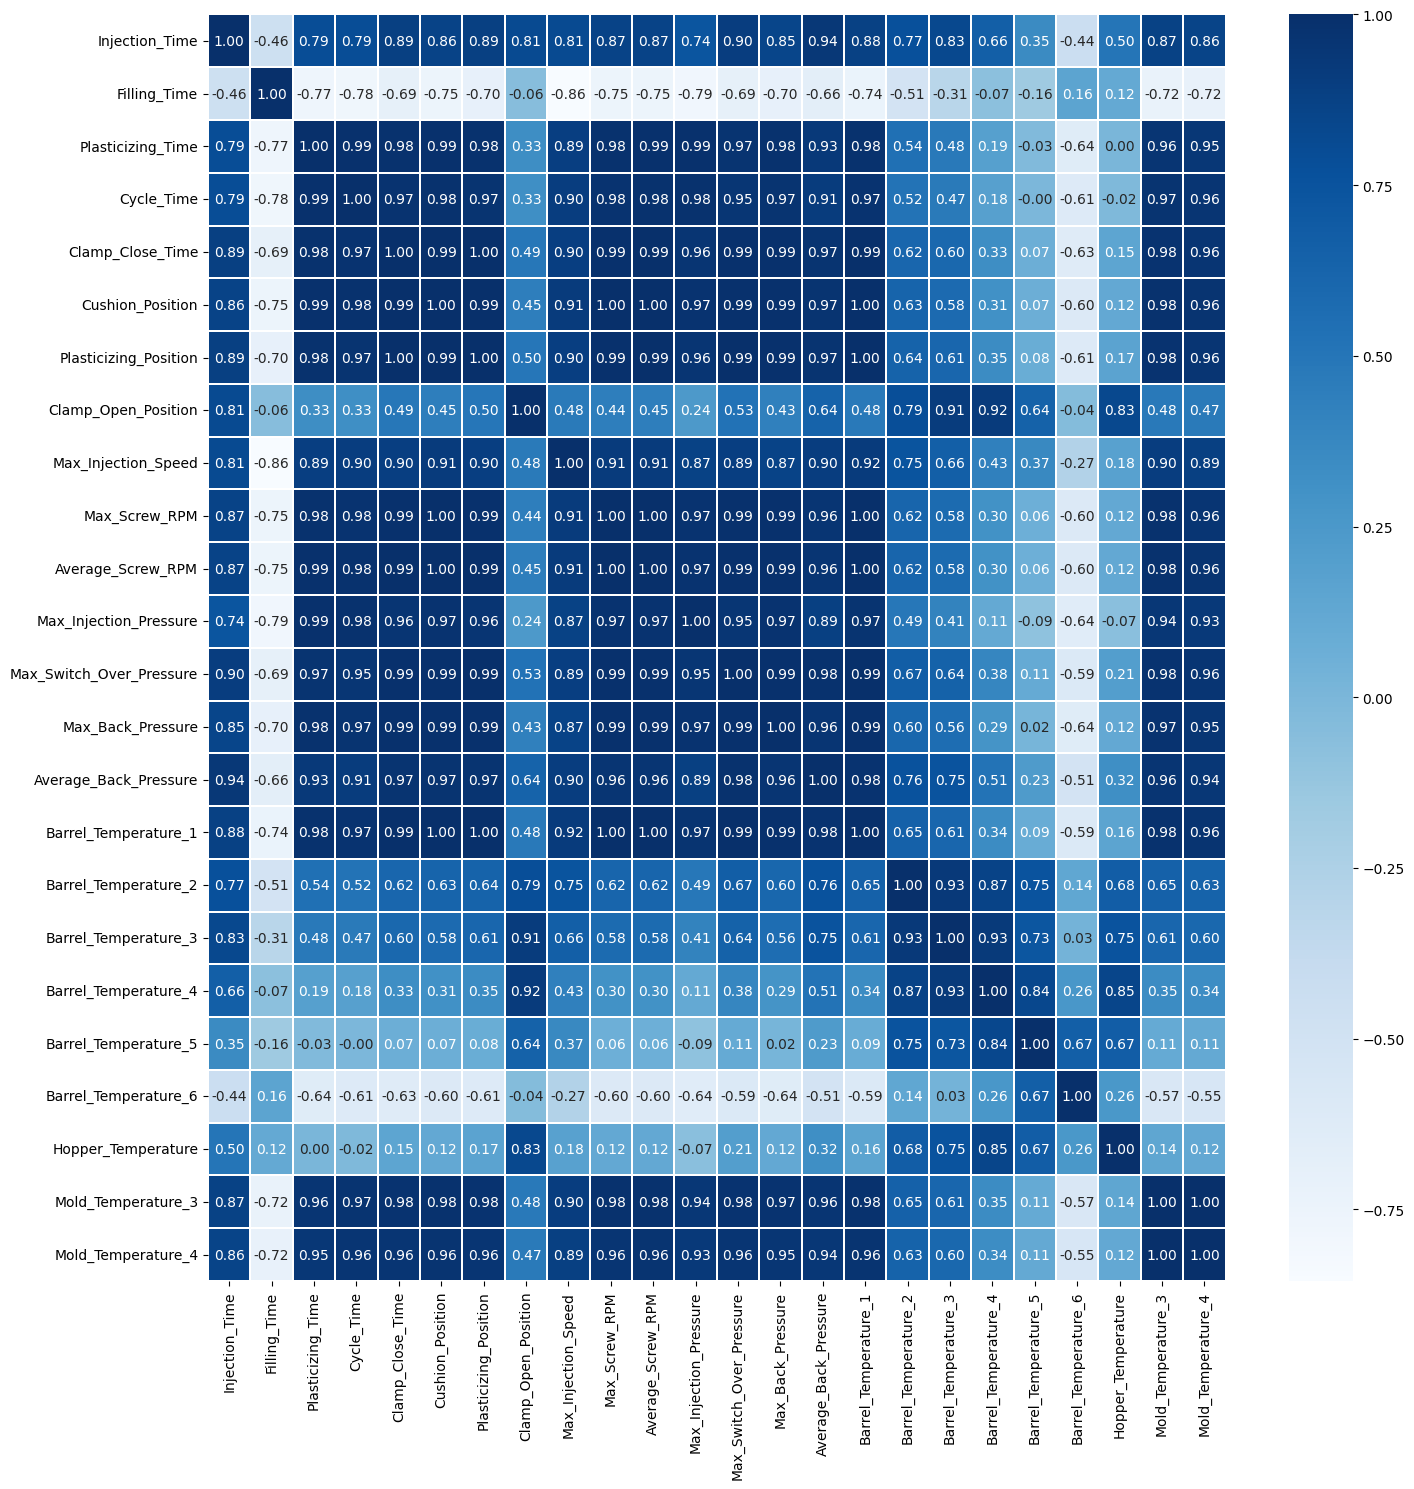

In [7]:
plt.subplots(figsize=(15,15))
sns.heatmap(data=unlabeled_cn7.corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()

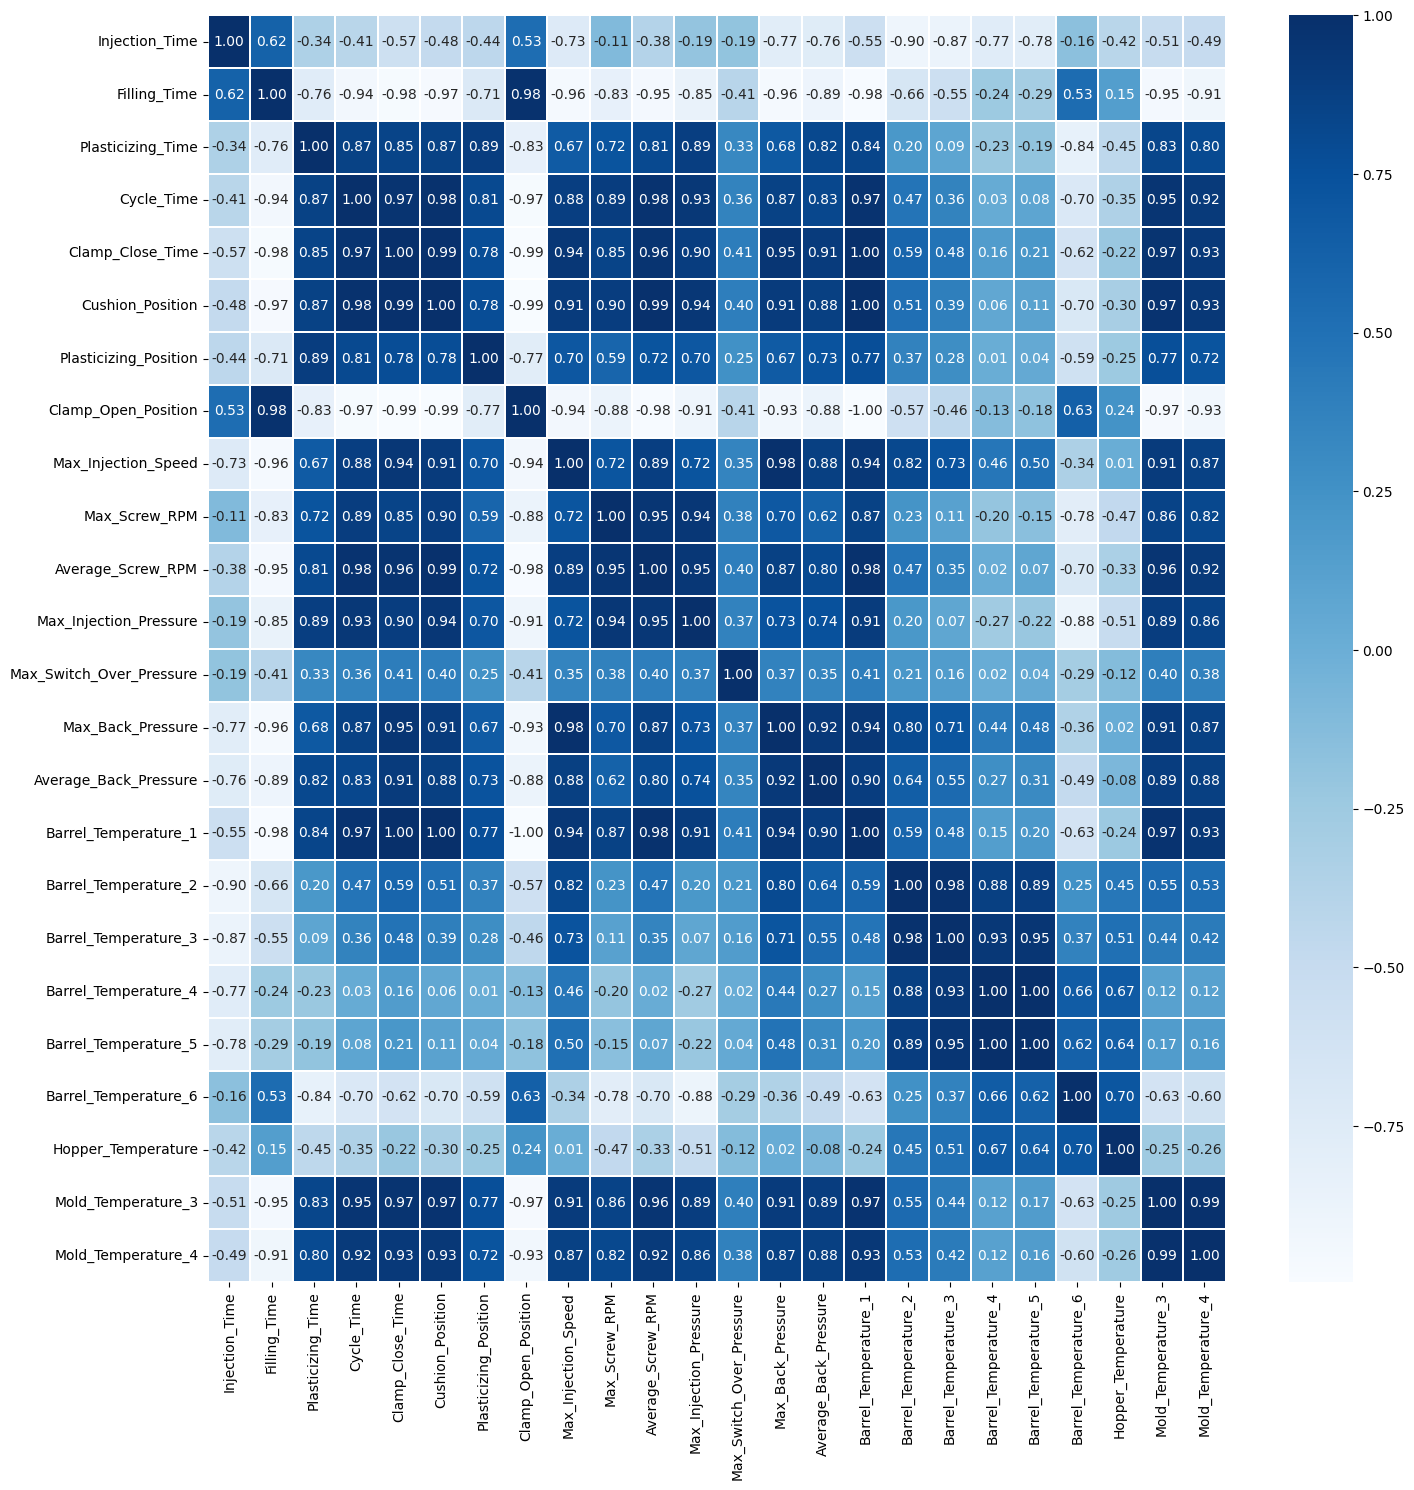

In [13]:
plt.subplots(figsize=(15,15))
sns.heatmap(data=unlabeled_rg3.corr(), annot=True, fmt='.2f', linewidths=0.1, cmap='Blues')
plt.tight_layout()

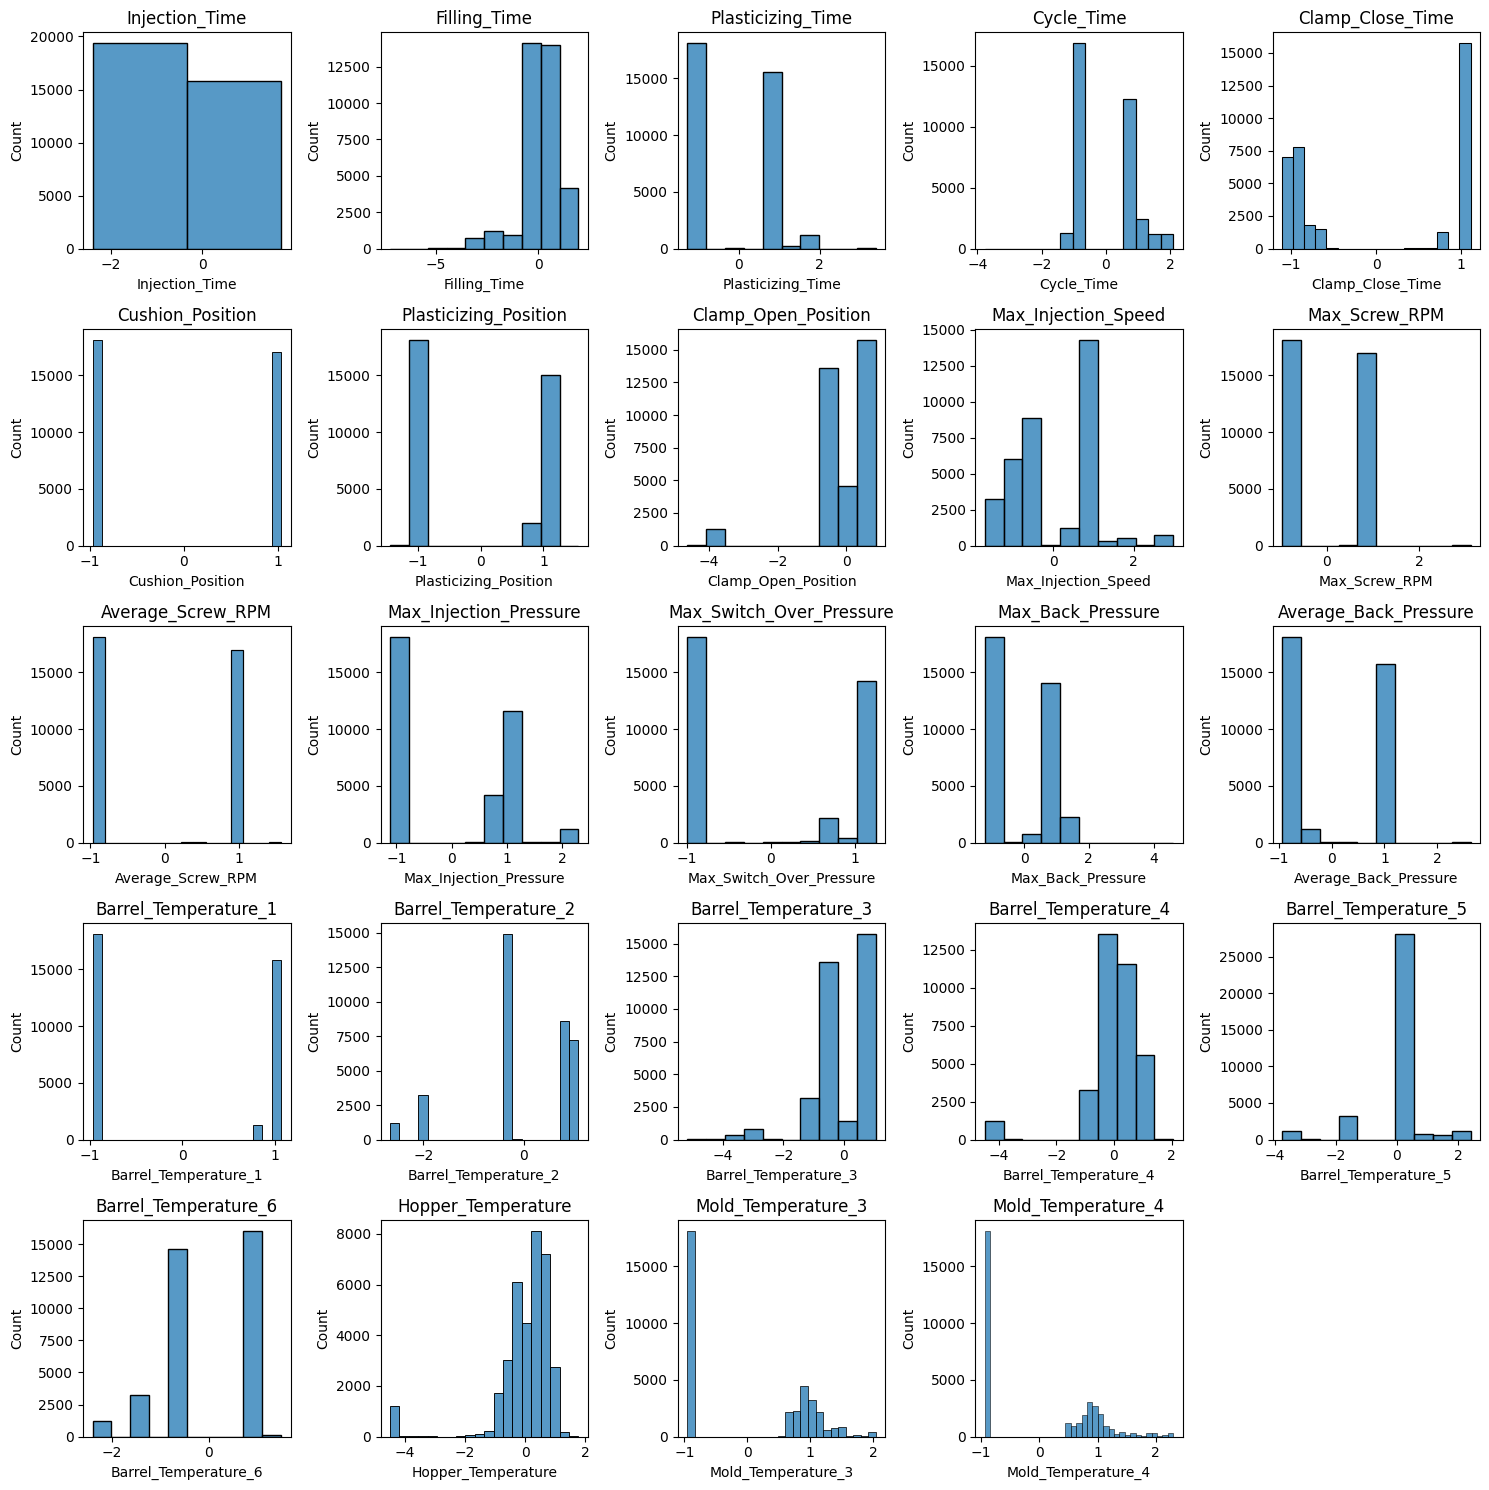

In [21]:
plt.figure(figsize=(15, 15))

bin = [2,10,10,15,17,20,10,10,10,10,15,10,10,10,10,20,20,10,10,10,10,20,25,35,35]

for index, value in enumerate(unlabeled_cn7.columns):
    plt.subplot(5, 5, index + 1)
    sns.histplot(data=unlabeled_cn7[value], bins=bin[index], edgecolor='black')
    plt.title(value)

plt.tight_layout()

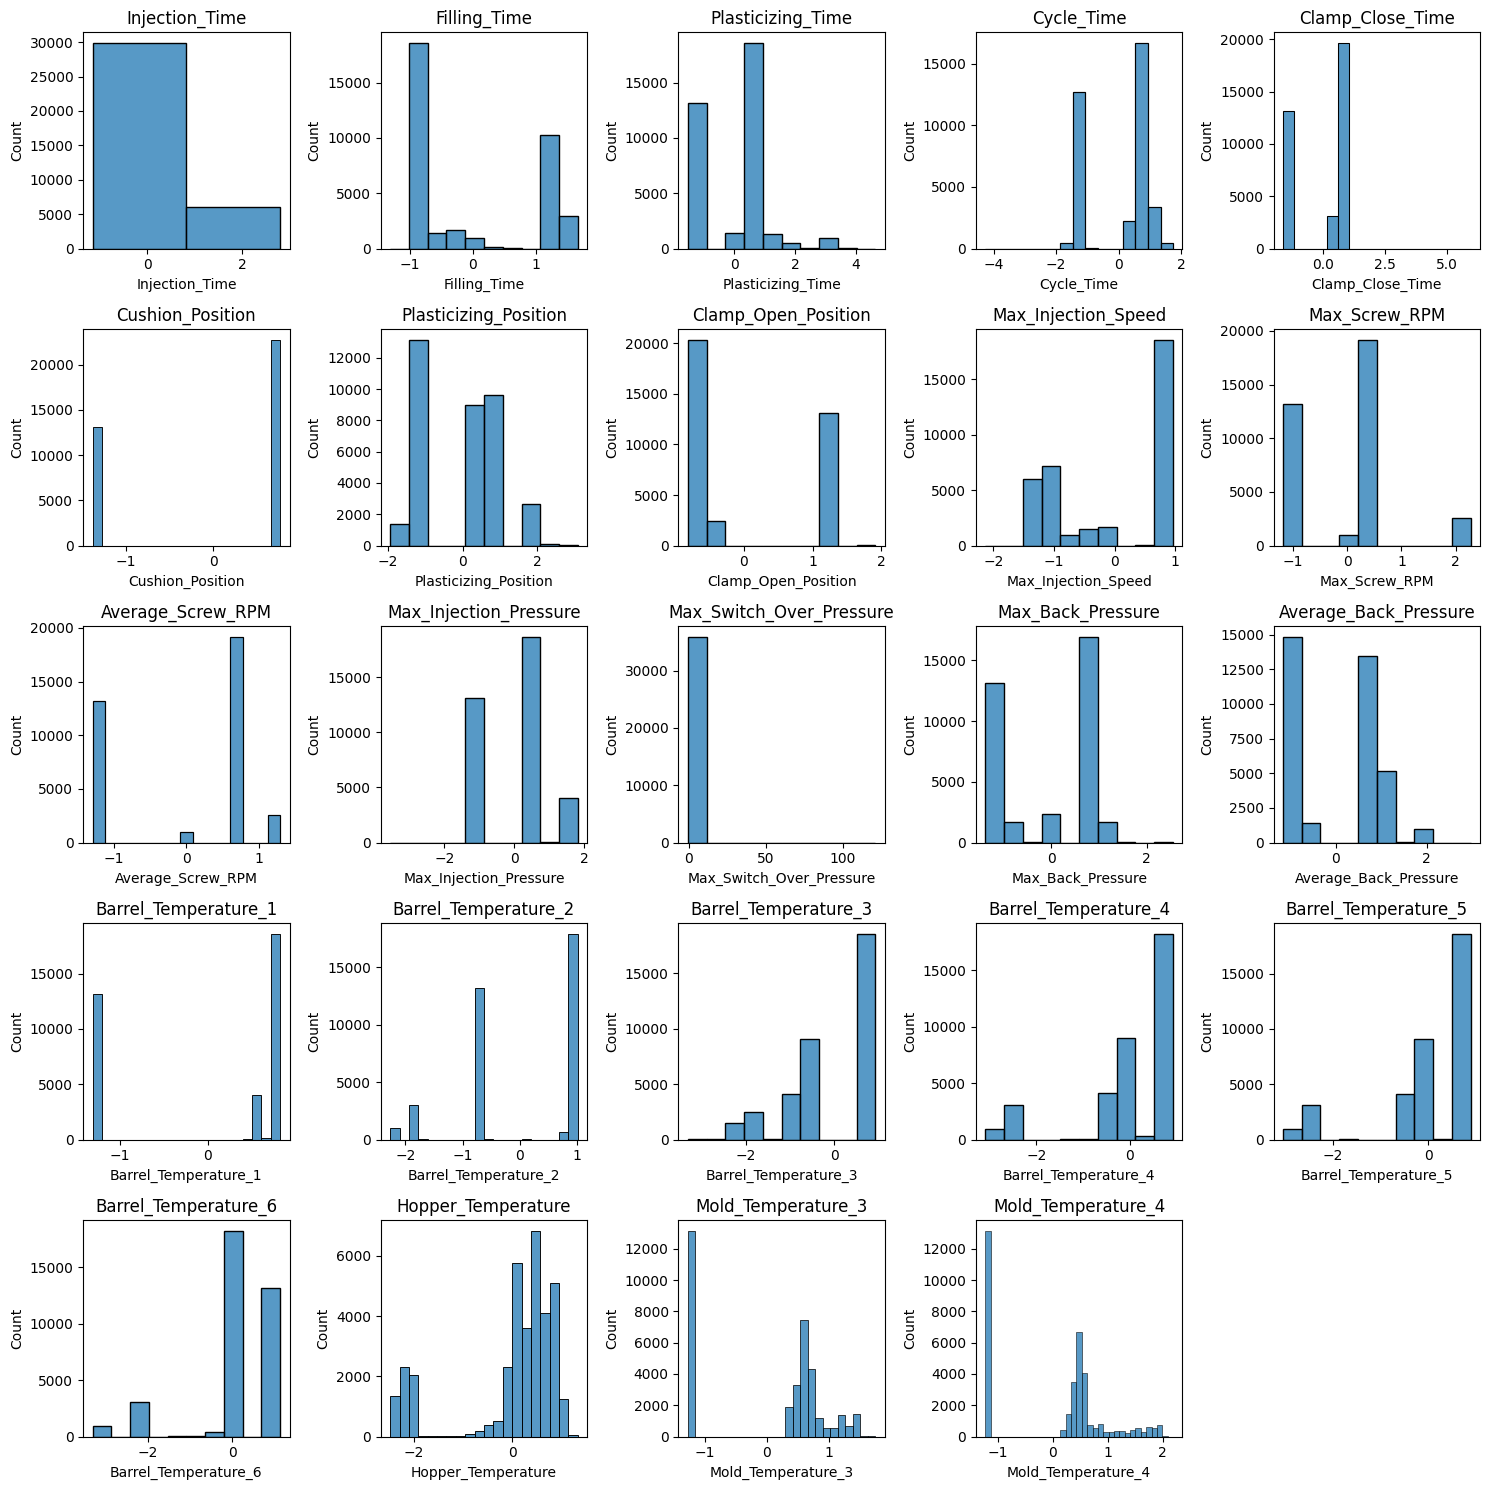

In [22]:
plt.figure(figsize=(15, 15))

bin = [2,10,10,15,17,20,10,10,10,10,15,10,10,10,10,20,20,10,10,10,10,20,25,35,35]

for index, value in enumerate(unlabeled_rg3.columns):
    plt.subplot(5, 5, index + 1)
    sns.histplot(data=unlabeled_rg3[value], bins=bin[index], edgecolor='black')
    plt.title(value)

plt.tight_layout()

In [26]:
np.repeat(['C','R'],[unlabeled_cn7.shape[0], unlabeled_rg3.shape[0]])

array(['C', 'C', 'C', ..., 'R', 'R', 'R'], dtype='<U1')

In [29]:
unlabeled_total = pd.concat([unlabeled_cn7, unlabeled_rg3], axis=0)
# Product 0 : 'CN7', 1: 'RG3'
unlabeled_total['product'] = np.repeat([0, 1],[unlabeled_cn7.shape[0], unlabeled_rg3.shape[0]])
print(unlabeled_total.shape)
unlabeled_total.head()

(71180, 25)


,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4,product
114610,1.346829,-2.768862,0.961909,1.843294,1.029767,1.031111,0.849819,0.861854,2.489188,1.025136,1.031548,0.494886,0.345152,0.183351,0.221579,1.015093,0.919876,0.846380,0.637023,2.099671,1.025241,-0.551566,0.756435,0.600810,0
114688,1.360046,-2.720306,0.963280,1.847956,1.029767,1.031048,0.863559,0.861854,2.446877,1.025136,1.031548,0.497896,0.348230,0.201286,0.228419,1.020221,0.988615,0.874453,0.703109,2.099671,1.074495,-0.503460,0.818567,0.700620,0
114919,1.355641,-2.720306,0.966020,1.843294,1.029767,1.031080,0.864246,0.861854,2.446877,1.025136,1.031548,0.497896,0.351308,0.171395,0.221579,1.014360,0.862594,0.874453,0.637023,2.293882,0.975987,-0.599672,0.694303,0.574194,0
115304,1.360046,-2.720306,0.960539,1.843294,1.029767,1.031143,0.864246,0.861854,2.455339,1.025136,1.031548,0.497896,0.332839,0.183351,0.221579,1.017290,0.919876,0.944634,0.785717,2.099671,1.058077,-0.599672,0.531206,0.394536,0
115582,1.360046,-2.720306,0.967391,1.847956,1.029767,1.031048,0.864933,0.861854,2.446877,1.018644,1.031548,0.497896,0.326683,0.165417,0.221579,1.018756,0.851137,0.916562,0.670066,2.177355,0.992405,-0.599672,0.585571,0.434460,0


In [32]:
unlabeled_total.info()

<class 'pandas.core.frame.DataFrame'>
Index: 71180 entries, 114610 to 795309
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Injection_Time            71180 non-null  float64
 1   Filling_Time              71180 non-null  float64
 2   Plasticizing_Time         71180 non-null  float64
 3   Cycle_Time                71180 non-null  float64
 4   Clamp_Close_Time          71180 non-null  float64
 5   Cushion_Position          71180 non-null  float64
 6   Plasticizing_Position     71180 non-null  float64
 7   Clamp_Open_Position       71180 non-null  float64
 8   Max_Injection_Speed       71180 non-null  float64
 9   Max_Screw_RPM             71180 non-null  float64
 10  Average_Screw_RPM         71180 non-null  float64
 11  Max_Injection_Pressure    71180 non-null  float64
 12  Max_Switch_Over_Pressure  71180 non-null  float64
 13  Max_Back_Pressure         71180 non-null  float64
 14  Avera

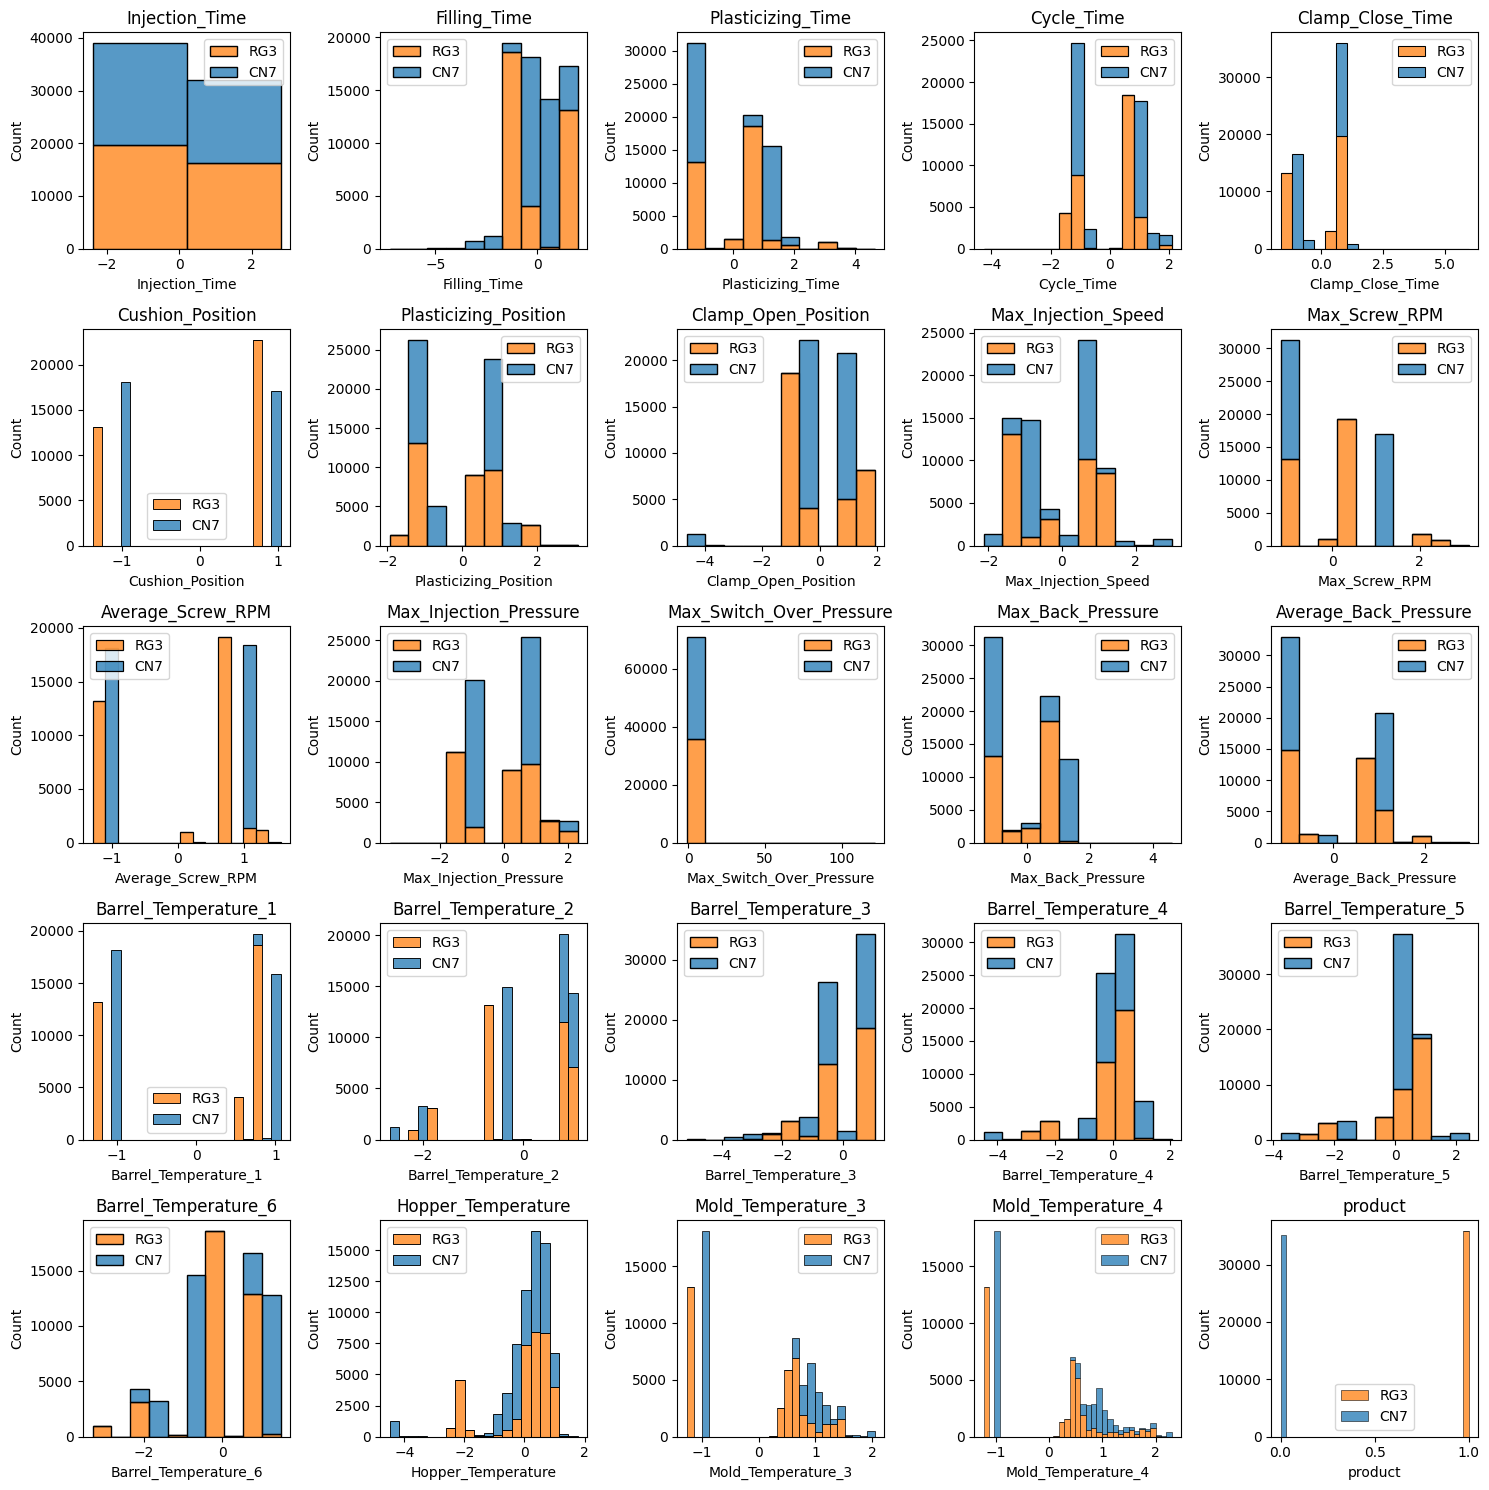

In [35]:
# check the distribution of features for each products(cn7, rg3)
plt.figure(figsize=(15, 15))

bin = [2,10,10,15,17,20,10,10,10,10,15,10,10,10,10,20,20,10,10,10,10,20,25,35,35]

for index, value in enumerate(unlabeled_total.columns):
    plt.subplot(5, 5, index + 1)
    sns.histplot(data=unlabeled_total, x=value, multiple='stack', hue='product',bins=bin[index], edgecolor='black')
    plt.title(value)
    plt.legend(['RG3','CN7'])

plt.tight_layout()

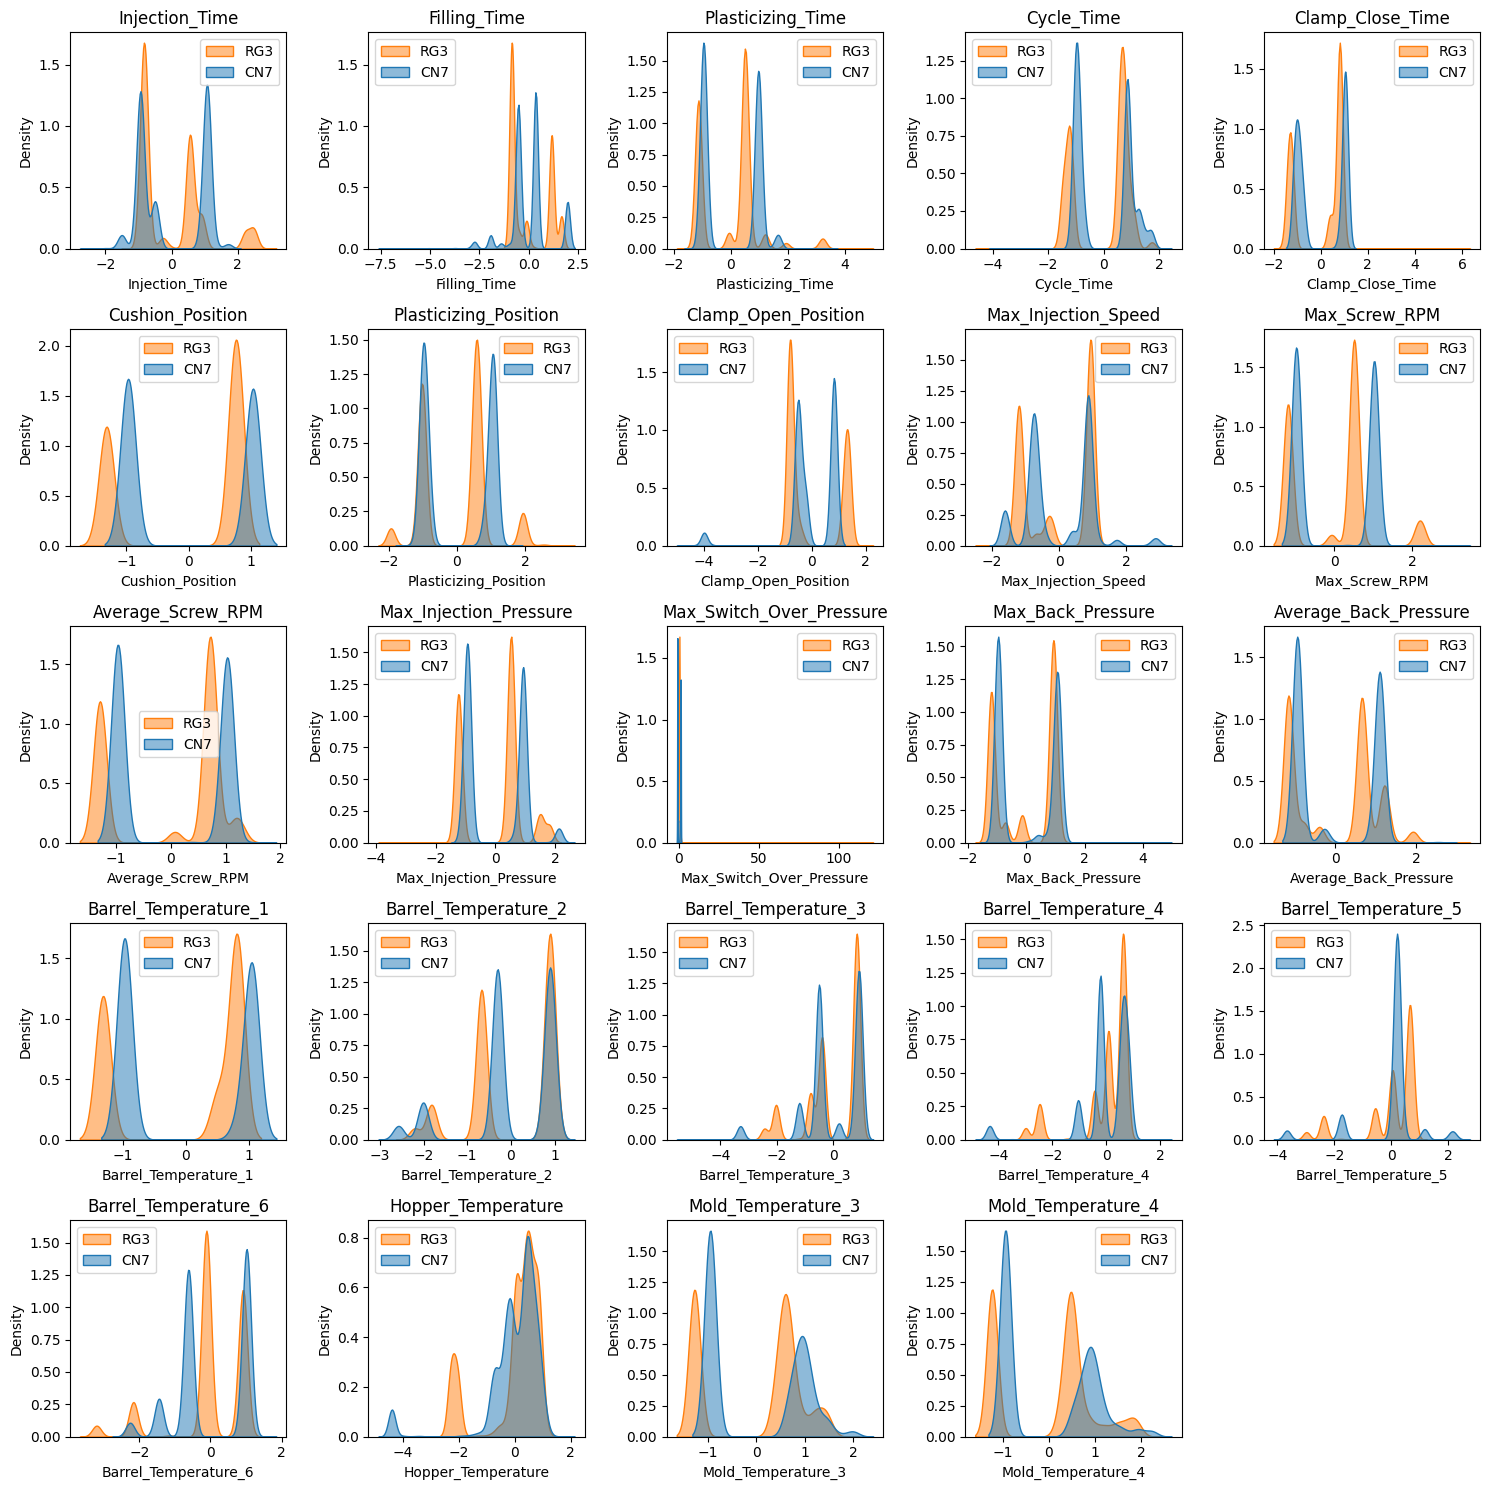

In [36]:
# plot density plots for each feature in the CN7 dataset
# Normalize the density independently for each class (Pass/Fail) to better visualize the distribution differences
plt.figure(figsize=(15, 15))
for index, value in enumerate(unlabeled_total.columns):
    if value=='product':
        continue
    plt.subplot(5, 5, index + 1)
    sns.kdeplot(data=unlabeled_total, x=value, hue='product', fill=True, common_norm=False, alpha=0.5)
    plt.title(value)
    plt.legend(['RG3', 'CN7'])
plt.tight_layout()

#### 0-1. 데이터 전처리

`sklearn` 패키지에서 제공하는 `StandardScaler`를 사용하여 데이터 정규화

In [37]:
from sklearn.preprocessing import StandardScaler

data = [labeled_cn7, labeled_rg3, unlabeled_cn7, unlabeled_rg3]
for d in data:
    for column in d.columns:
        if column != 'PassOrFail':
            sc = StandardScaler()
            d[[column]] = sc.fit_transform(d[[column]])

### 1. 모델 구축 ① ; 필요 함수 생성

전체적인 준지도 학습 방법
- 클래스 변수가 있는 데이터를 사용하여 일차적으로 모델을 학습
- 이후 클래스 변수가 없는 데이터를 선별적으로 추가하는 과정을 반복하며 모델을 개선

    ![alt text](image-3.png)

#### 1-1. 절댓값 반환 함수

학습된 모델이 예측하는 클래스별 확률값 중에서 큰 값의 절댓값을 반환하는 함수를 생성
- 이 함수는 준지도 학습 상황에서 엔트로피 최소화를 위한 계산에 사용됨

In [38]:
# 행렬을 입력으로 받음
# row: data point, col: class(0,1) 형식, value: obs별 클래스에 속할 확률
def confident_prediction(df):
    result=[]

    for i in range(len(df)):
        if df[i][0] >= df[i][1]:
            result.append(df[i][0])
        else:
            result.append(df[i][1])
    return result

# 심층 신경망에서 사용
# 0~1 사이의 값을 가지는 벡터를 입력으로 받음
# 0, 1 중 가까운 클래스 변수만 선택하여 하나의 벡터로 출력
def confident_prediction_dnn(df):
    result = []

    for i in range(len(df)):
        if df[i]>=0.5:
            result.append(df[i])
        else:
            result.append(1-df[i])
    return result


#### 1-2. 평가지표 함수

In [39]:
def evaluation(y, y_pred):
    print('Accuracy: {:.2f}'.format(accuracy_score(y, y_pred)))
    print('Precision: {:.2f}'.format(precision_score(y, y_pred)))
    print('Recall: {:.2f}'.format(recall_score(y, y_pred)))
    print('ROC-AUC Score: {:.2f}'.format(roc_auc_score(y, y_pred)))
    print('F1 Score: ', f1_score(y, y_pred))
    print('Confusion Matrix')
    print(confusion_matrix(y, y_pred))

### 2. 모델 구축 ②

#### 2-1. 학습/평가 데이터 분리

train, test dataset을 층화 추출법으로 분리

*층화 추출법*
- 데이터의 클래스 변수의 비율을 고려하여 학습/평가 데이터를 분리하는 방법
- 비율이 학습과 평가 시에 동일하게 유지되므로 과적합을 방지하고 모델의 성능을 향상시킬 수 있음
- `sklearn.model_selection.StratifiedShuffleSplit`